In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import stats
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import warnings

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/manutencao_preditiva.csv')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams['font.size'] = 12


Distribuição da variável 'Tipo da Falha':
Tipo da Falha
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

Percentual por tipo de falha:
No Failure: 96.52%
Heat Dissipation Failure: 1.12%
Power Failure: 0.95%
Overstrain Failure: 0.78%
Tool Wear Failure: 0.45%
Random Failures: 0.18%


<ipython-input-2-969b454bf852>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='Tipo da Falha', data=df, palette='Blues_r',


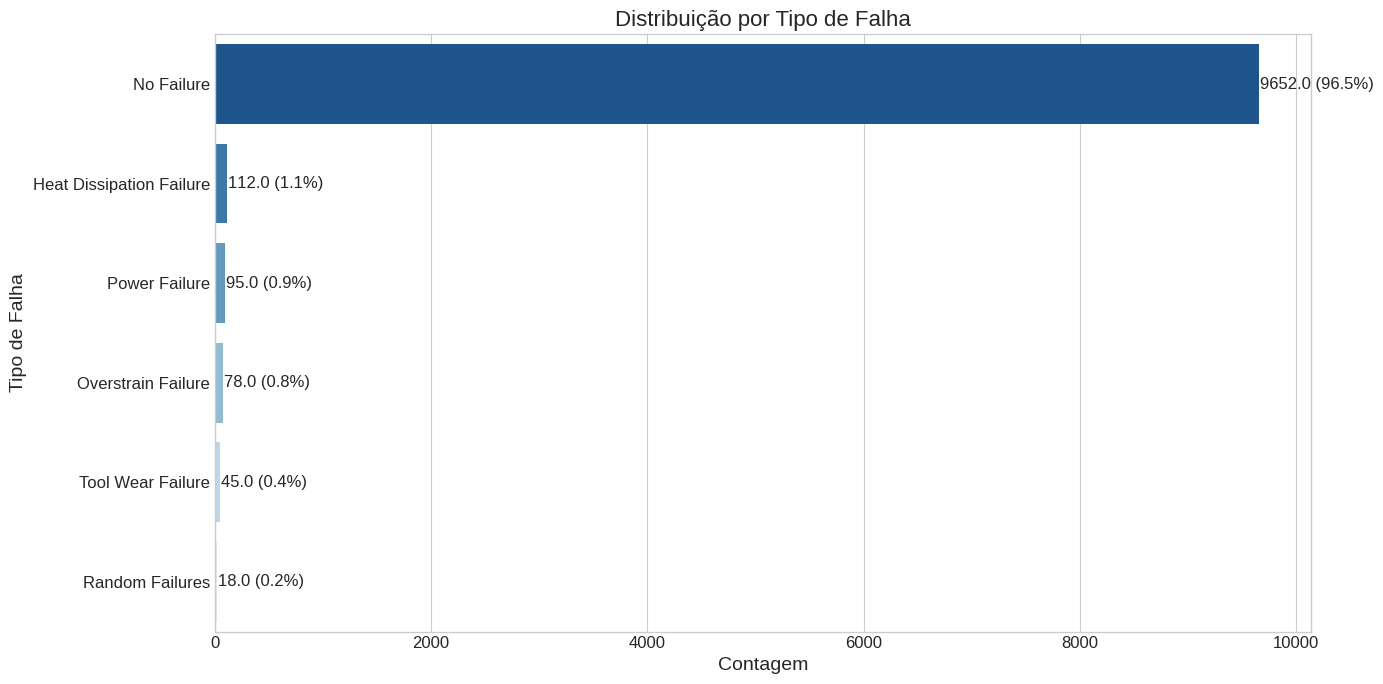

In [ ]:
print("\nDistribuição da variável 'Tipo da Falha':")
falha_counts = df['Tipo da Falha'].value_counts()
print(falha_counts)
falha_percent = df['Tipo da Falha'].value_counts(normalize=True) * 100
print("\nPercentual por tipo de falha:")
for falha, perc in falha_percent.items():
    print(f"{falha}: {perc:.2f}%")


plt.figure(figsize=(14, 7))
ax = sns.countplot(y='Tipo da Falha', data=df, palette='Blues_r',
                  order=df['Tipo da Falha'].value_counts().index)
plt.title('Distribuição por Tipo de Falha', fontsize=16)
plt.xlabel('Contagem', fontsize=14)
plt.ylabel('Tipo de Falha', fontsize=14)




for p in ax.patches:
    width = p.get_width()
    ax.text(width + 10, p.get_y() + p.get_height()/2, f'{width} ({width/len(df)*100:.1f}%)',
            va='center', fontsize=12)


plt.tight_layout()
plt.show()


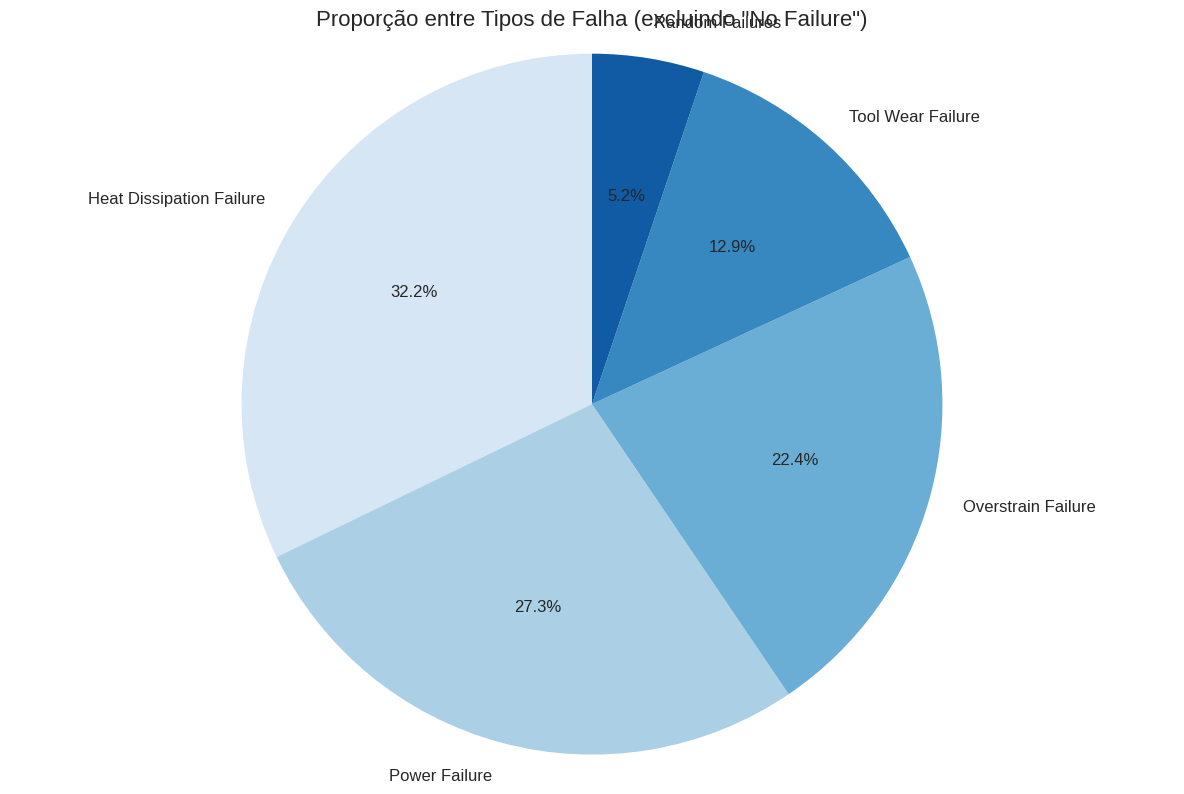

In [ ]:
plt.figure(figsize=(12, 8))
falhas_subset = falha_counts[falha_counts.index != 'No Failure']
plt.pie(falhas_subset, labels=falhas_subset.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('Blues', n_colors=len(falhas_subset)))
plt.title('Proporção entre Tipos de Falha (excluindo "No Failure")', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()


Total de registros: 10000
Total de falhas por dissipação de calor: 112
Total de outras falhas: 227
Total de não falhas: 9661

=== Estatísticas Descritivas por Grupo ===

Estatísticas para falhas por dissipação de calor:
       Temperatura Ar [K]  Temperatura Processo [K]  Velocidade Rotacao [rpm]  \
count          112.000000                112.000000                112.000000   
mean           302.567857                310.799107               1337.964286   
std              0.604371                  0.644938                 34.371036   
min            300.800000                309.400000               1212.000000   
25%            302.100000                310.300000               1323.250000   
50%            302.450000                310.700000               1346.000000   
75%            303.125000                311.300000               1363.250000   
max            303.700000                312.200000               1379.000000   

       Torque [Nm]  Desgaste Ferramenta [min]  
co

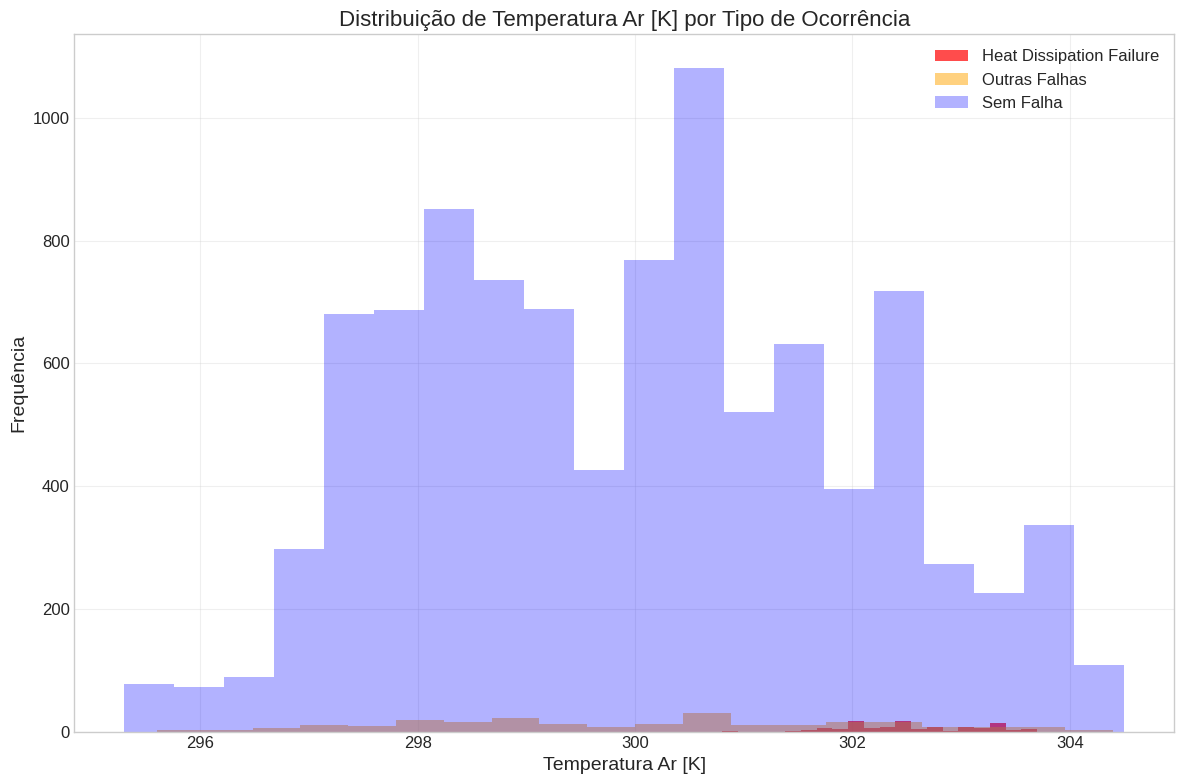

<ipython-input-5-4817528c665a>:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Heat Dissipation Failure', 'Outras Falhas', 'Sem Falha'],


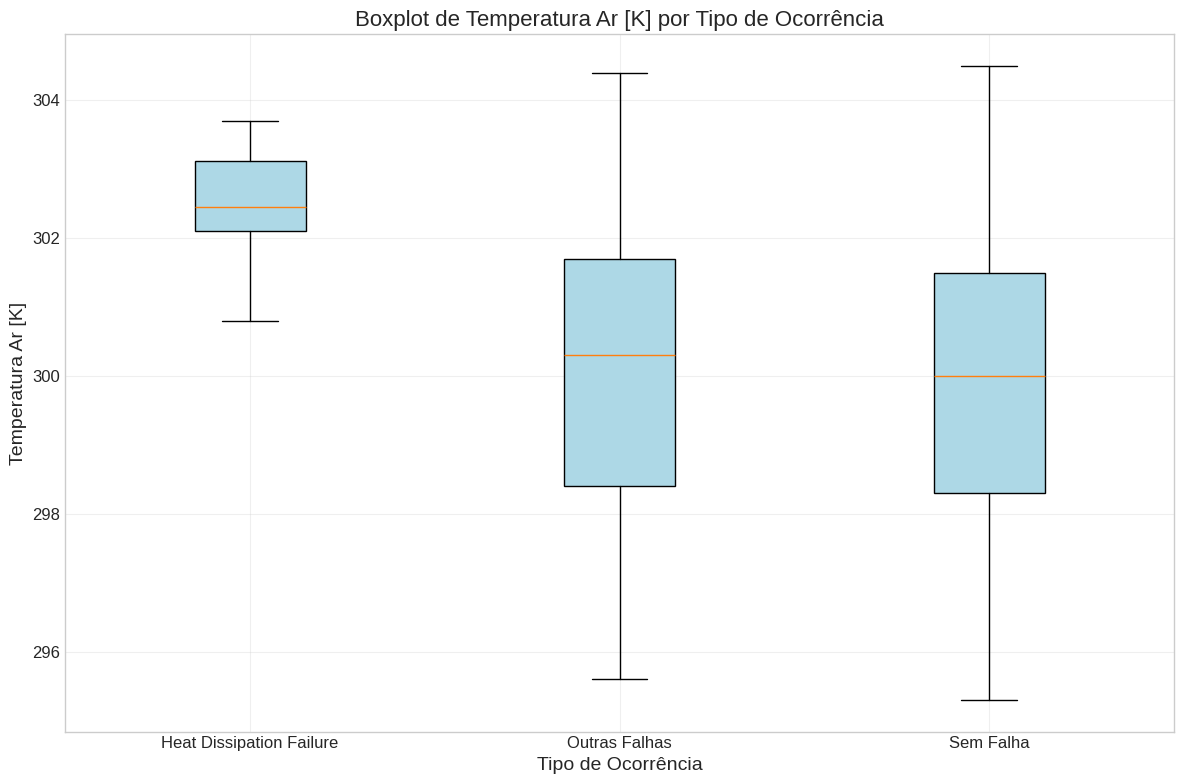

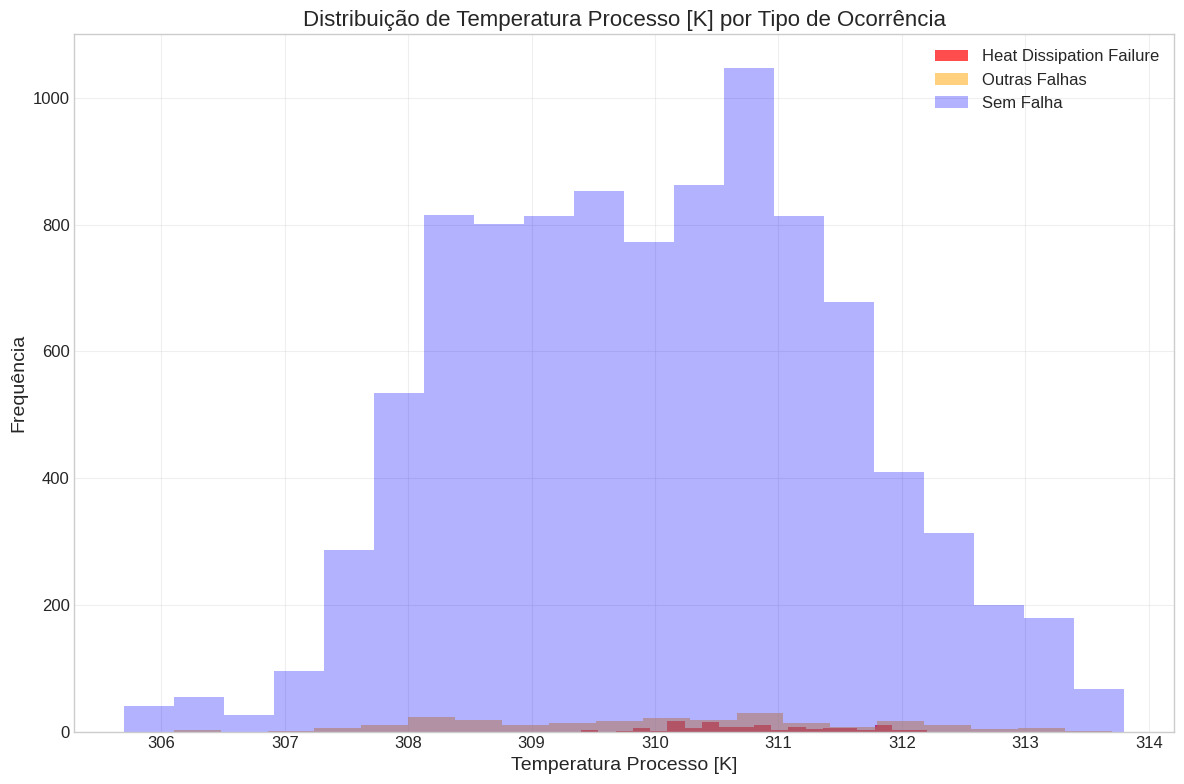

<ipython-input-5-4817528c665a>:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Heat Dissipation Failure', 'Outras Falhas', 'Sem Falha'],


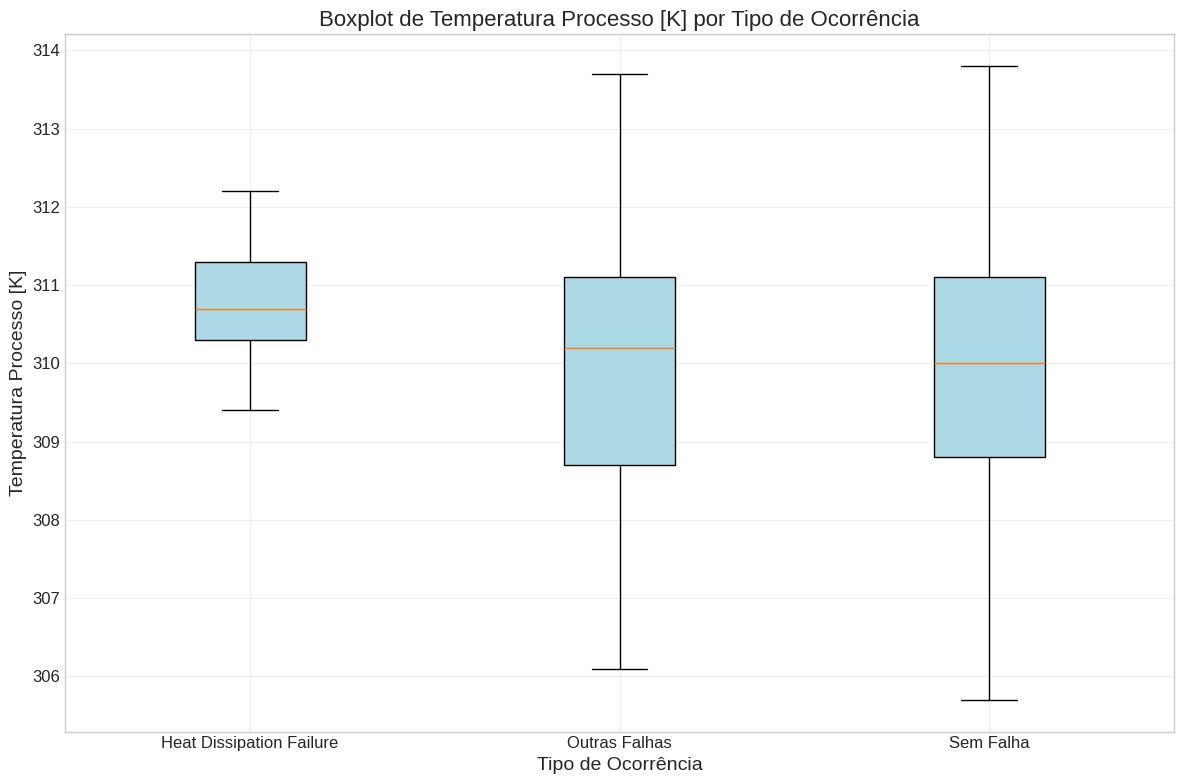

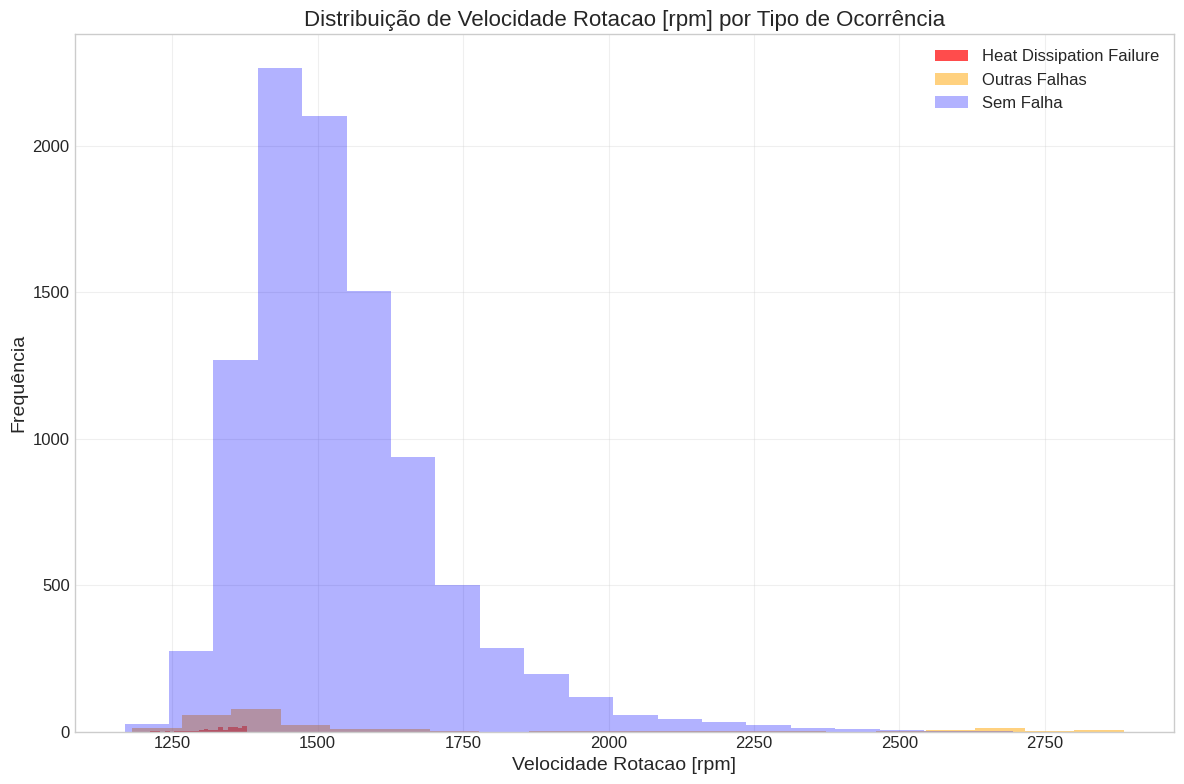

<ipython-input-5-4817528c665a>:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Heat Dissipation Failure', 'Outras Falhas', 'Sem Falha'],


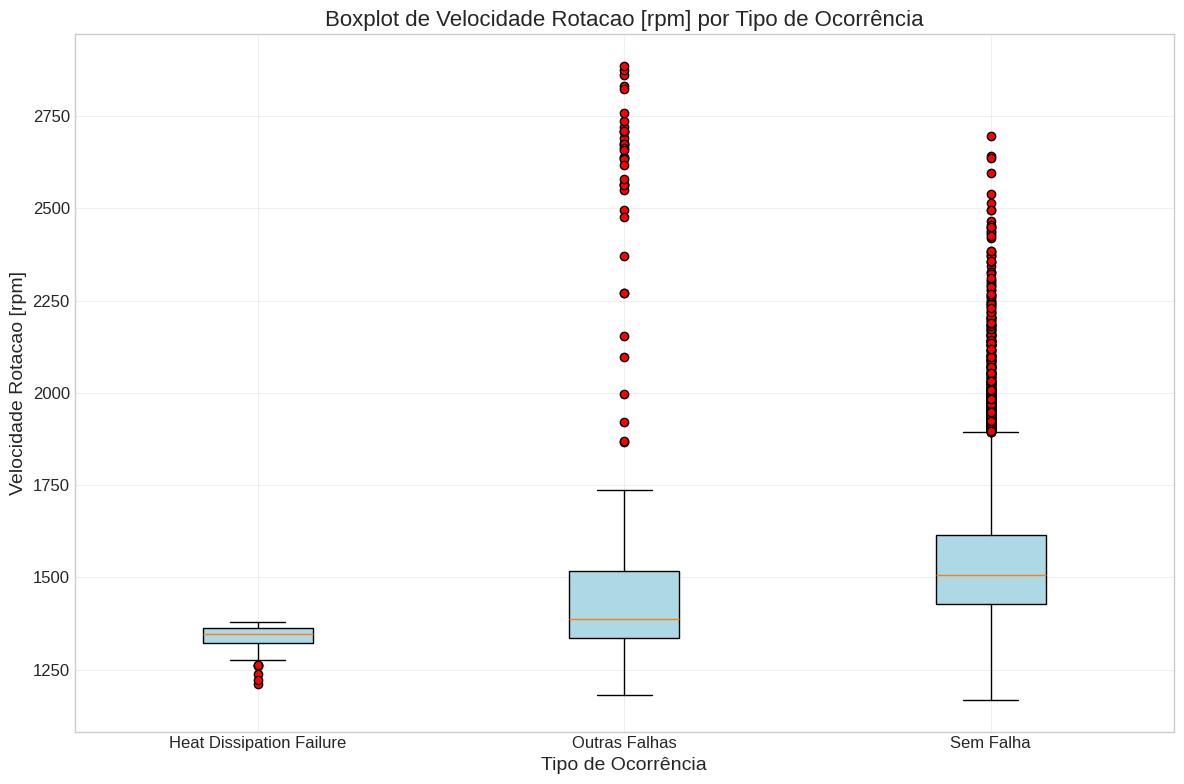

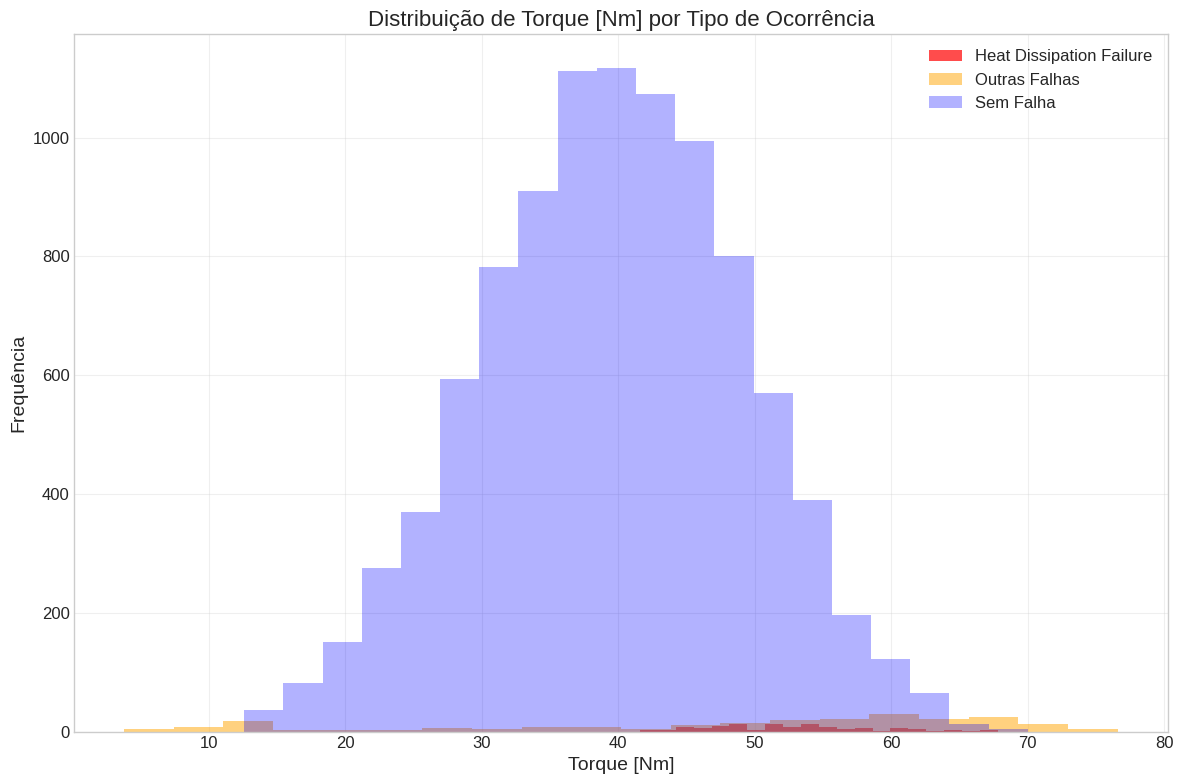

<ipython-input-5-4817528c665a>:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Heat Dissipation Failure', 'Outras Falhas', 'Sem Falha'],


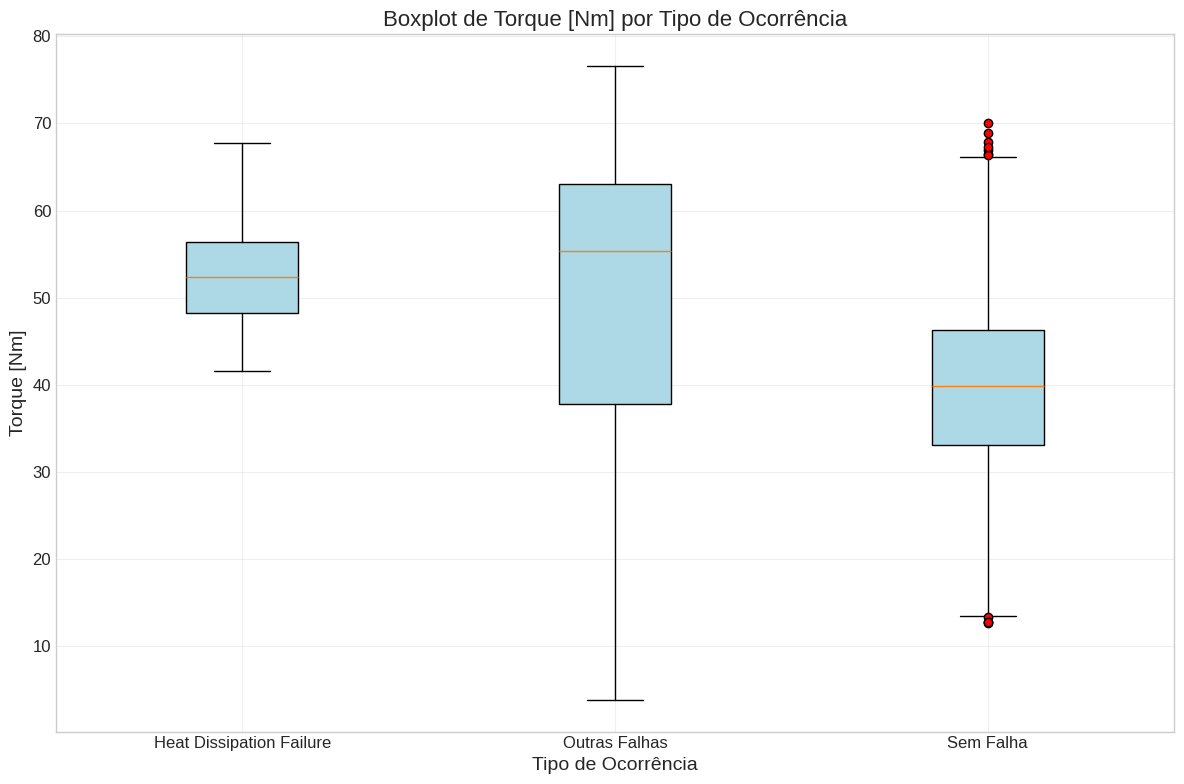

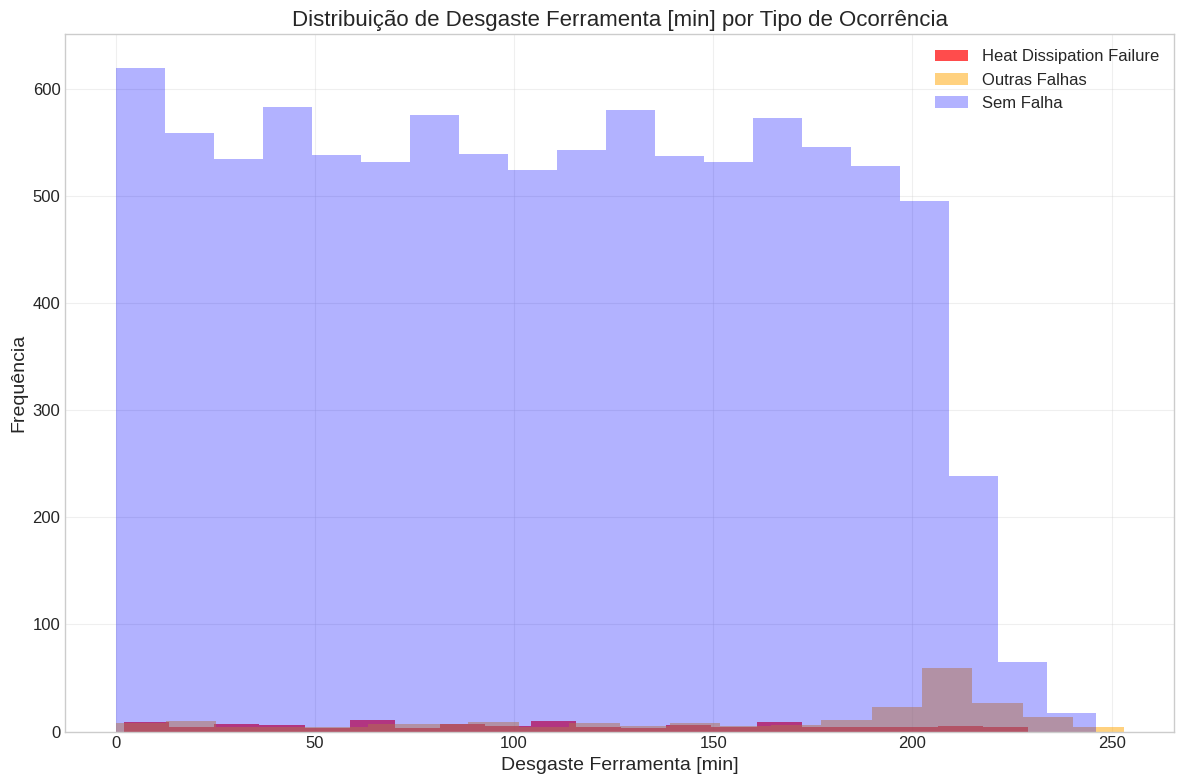

<ipython-input-5-4817528c665a>:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Heat Dissipation Failure', 'Outras Falhas', 'Sem Falha'],


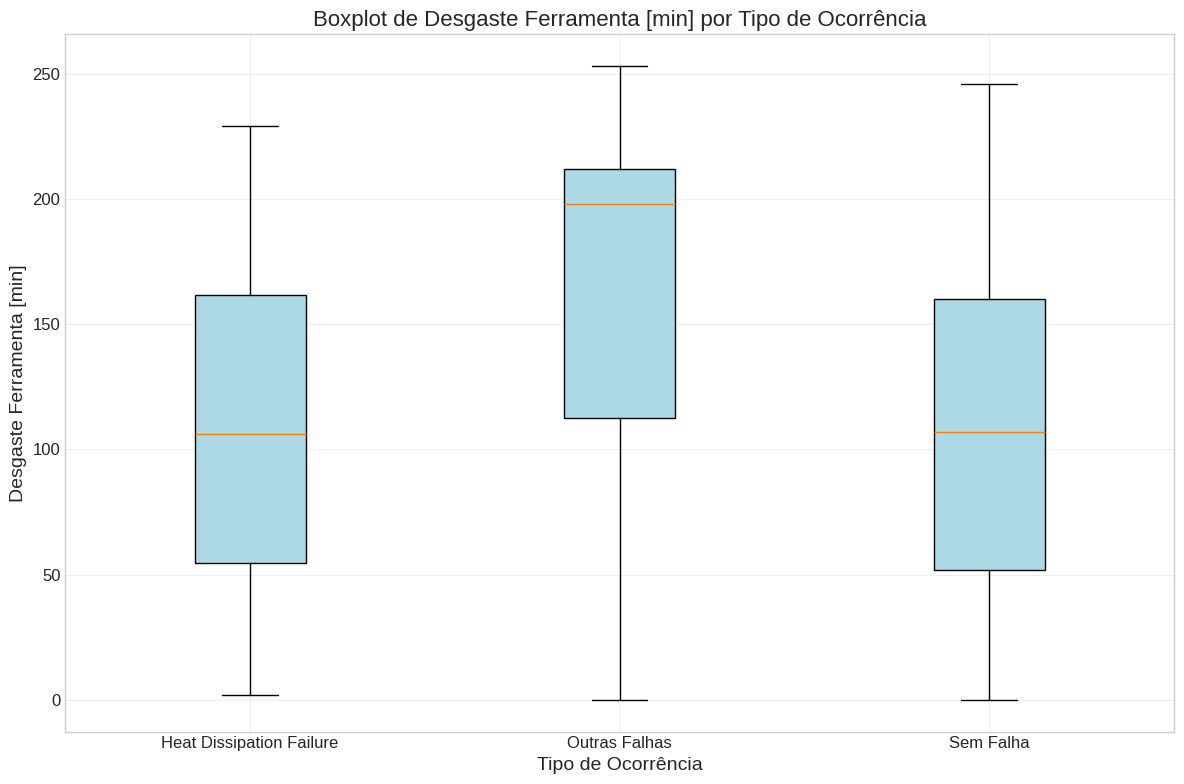

In [ ]:
# Coluna específica para falhas por dissipação de calor
df['Heat_Failure'] = (df['Tipo da Falha'] == 'Heat Dissipation Failure').astype(int)


# Identificando os diferentes grupos para comparação
heat_failures = df[df['Tipo da Falha'] == 'Heat Dissipation Failure']
other_failures = df[(df['Alvo'] == 1) & (df['Tipo da Falha'] != 'Heat Dissipation Failure')]
no_failures = df[df['Alvo'] == 0]


print(f"Total de registros: {len(df)}")
print(f"Total de falhas por dissipação de calor: {len(heat_failures)}")
print(f"Total de outras falhas: {len(other_failures)}")
print(f"Total de não falhas: {len(no_failures)}")


# 2. Análise Comparativa das Características entre Grupos


# 2.1 Estatísticas descritivas por grupo
print("\n=== Estatísticas Descritivas por Grupo ===")


# Variáveis numéricas para análise
numeric_cols = ['Temperatura Ar [K]', 'Temperatura Processo [K]',
                'Velocidade Rotacao [rpm]', 'Torque [Nm]', 'Desgaste Ferramenta [min]']


# Estatísticas para falhas por dissipação de calor
print("\nEstatísticas para falhas por dissipação de calor:")
print(heat_failures[numeric_cols].describe())


# Estatísticas para outras falhas
print("\nEstatísticas para outras falhas:")
print(other_failures[numeric_cols].describe())


# Estatísticas para não falhas
print("\nEstatísticas para não falhas:")
print(no_failures[numeric_cols].describe())


# 2.2 Visualização comparativa das distribuições por grupo
for col in numeric_cols:
    plt.figure(figsize=(12, 8))

    # Histograma para cada grupo
    plt.hist(heat_failures[col], bins=20, alpha=0.7, label='Heat Dissipation Failure', color='red')
    plt.hist(other_failures[col], bins=20, alpha=0.5, label='Outras Falhas', color='orange')
    plt.hist(no_failures[col], bins=20, alpha=0.3, label='Sem Falha', color='blue')

    plt.title(f'Distribuição de {col} por Tipo de Ocorrência', fontsize=16)
    plt.xlabel(col, fontsize=14)
    plt.ylabel('Frequência', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Boxplot para comparação
    plt.figure(figsize=(12, 8))
    data_to_plot = [heat_failures[col], other_failures[col], no_failures[col]]
    plt.boxplot(data_to_plot, labels=['Heat Dissipation Failure', 'Outras Falhas', 'Sem Falha'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                flierprops=dict(markerfacecolor='red', marker='o'))

    plt.title(f'Boxplot de {col} por Tipo de Ocorrência', fontsize=16)
    plt.xlabel('Tipo de Ocorrência', fontsize=14)
    plt.ylabel(col, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Total de registros com falha: 348
Tipos de falha encontrados: ['Power Failure' 'Tool Wear Failure' 'Overstrain Failure'
 'Random Failures' 'Heat Dissipation Failure']
Contagem por tipo de falha:
Tipo da Falha
Heat Dissipation Failure    112
Power Failure                95
Overstrain Failure           78
Tool Wear Failure            45
Random Failures              18
Name: count, dtype: int64


<ipython-input-6-3e24428efa89>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='Tipo da Falha', data=df_falhas, palette='viridis')


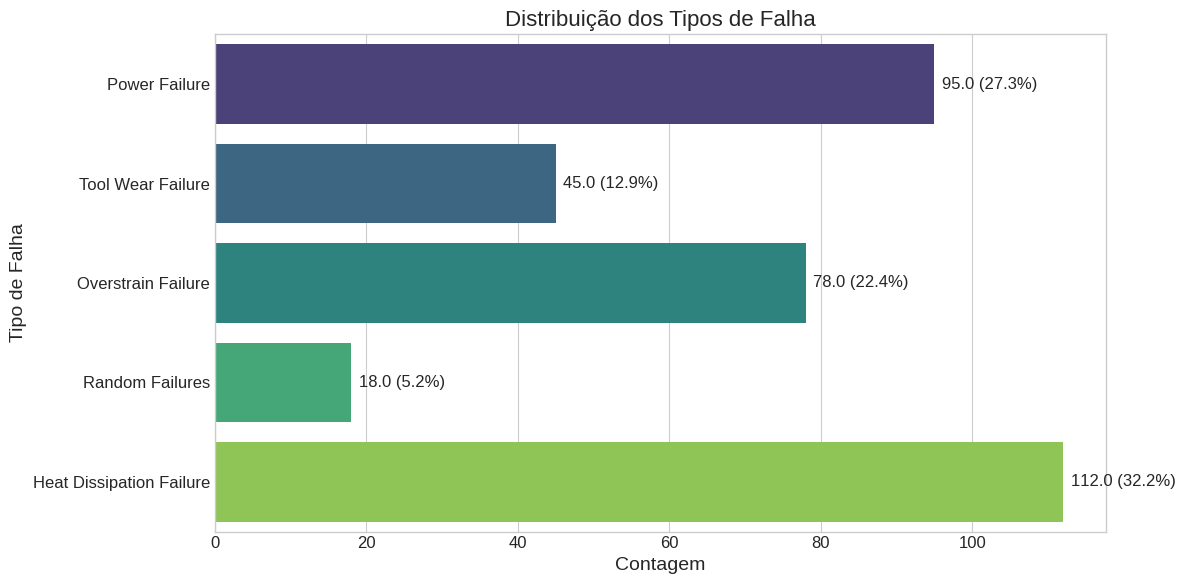

In [ ]:
df_falhas = df[df['Tipo da Falha'] != 'No Failure']
print(f"Total de registros com falha: {len(df_falhas)}")


tipos_falha = df_falhas['Tipo da Falha'].unique()
print("Tipos de falha encontrados:", tipos_falha)


contagem_falhas = df_falhas['Tipo da Falha'].value_counts()
print("Contagem por tipo de falha:")
print(contagem_falhas)

# distribuição dos tipos de falha
plt.figure(figsize=(12, 6))
ax = sns.countplot(y='Tipo da Falha', data=df_falhas, palette='viridis')
plt.title('Distribuição dos Tipos de Falha', fontsize=16)
plt.xlabel('Contagem', fontsize=14)
plt.ylabel('Tipo de Falha', fontsize=14)


# rótulos de contagem nas barras
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 1, p.get_y() + p.get_height()/2, f'{width} ({width/len(df_falhas)*100:.1f}%)',
            va='center', fontsize=12)


plt.tight_layout()
plt.show()



=== Estatísticas Descritivas por Tipo de Falha ===

Estatísticas para Power Failure:
       Temperatura Ar [K]  Temperatura Processo [K]  Velocidade Rotacao [rpm]  \
count           95.000000                 95.000000                 95.000000   
mean           300.075789                309.954737               1763.968421   
std              2.147127                  1.600450                620.829138   
min            295.700000                306.200000               1200.000000   
25%            298.400000                308.700000               1312.500000   
50%            300.400000                310.200000               1386.000000   
75%            301.800000                311.000000               2563.500000   
max            304.000000                313.200000               2886.000000   

       Torque [Nm]  Desgaste Ferramenta [min]  
count    95.000000                  95.000000  
mean     48.514737                 101.884211  
std      26.788653                  64.3

<ipython-input-7-d61a0fade2e7>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Tipo da Falha', y=var, data=df_falhas, palette='viridis')


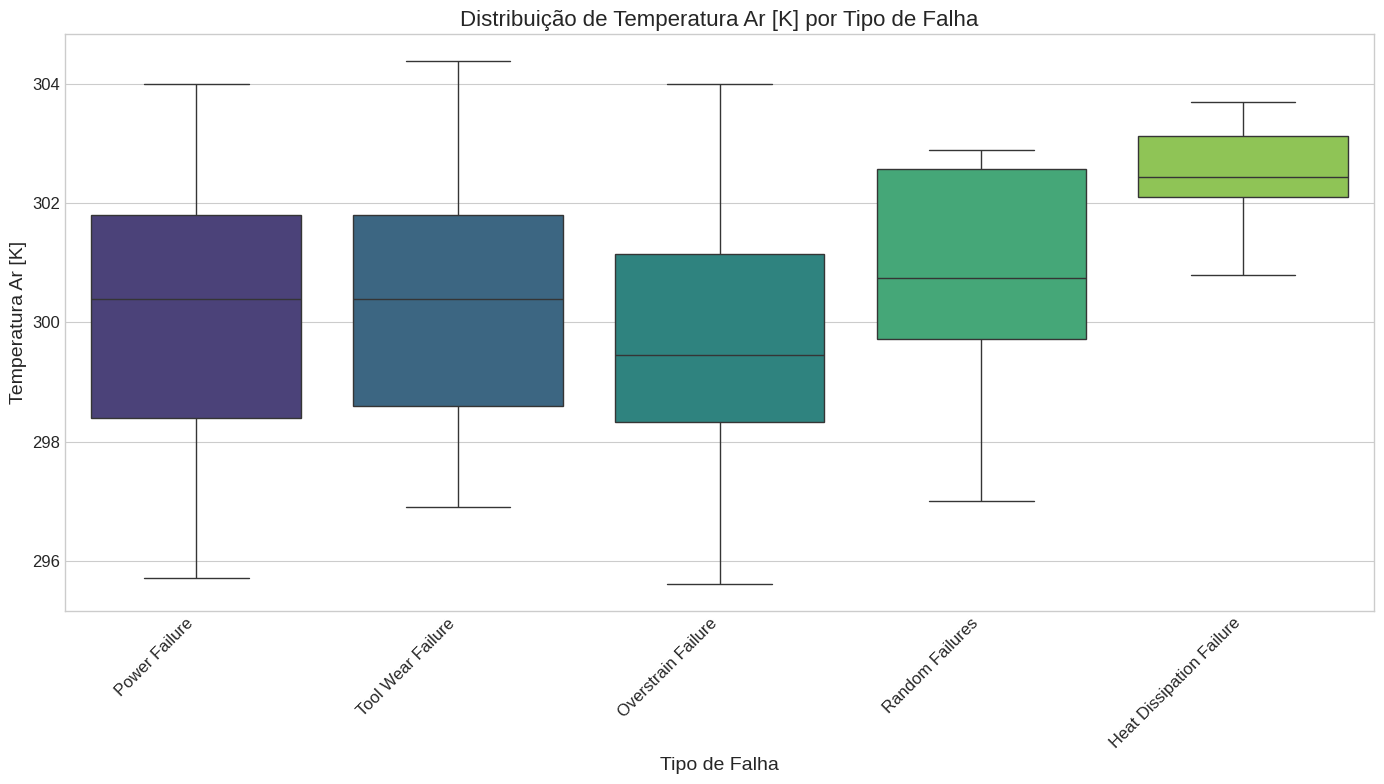

<ipython-input-7-d61a0fade2e7>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Tipo da Falha', y=var, data=df_falhas, palette='viridis')


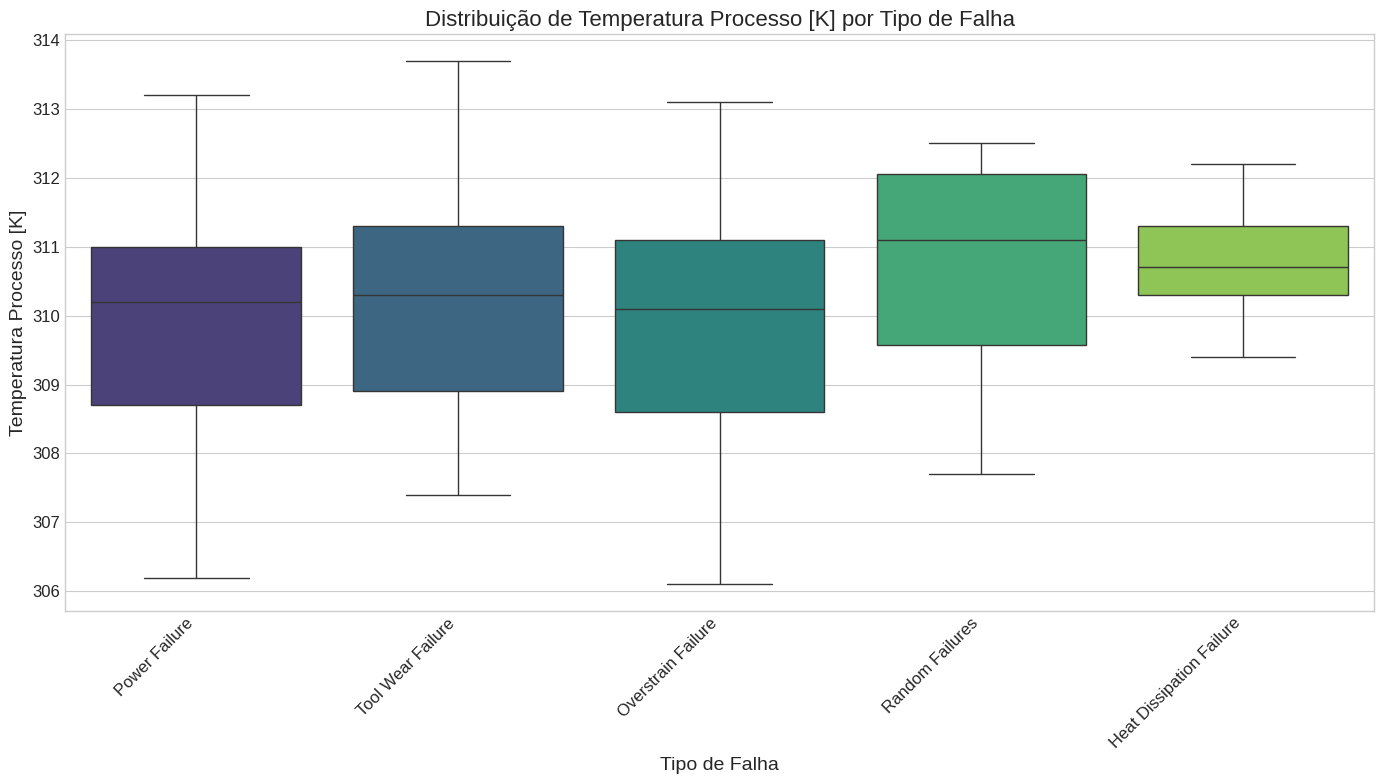

<ipython-input-7-d61a0fade2e7>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Tipo da Falha', y=var, data=df_falhas, palette='viridis')


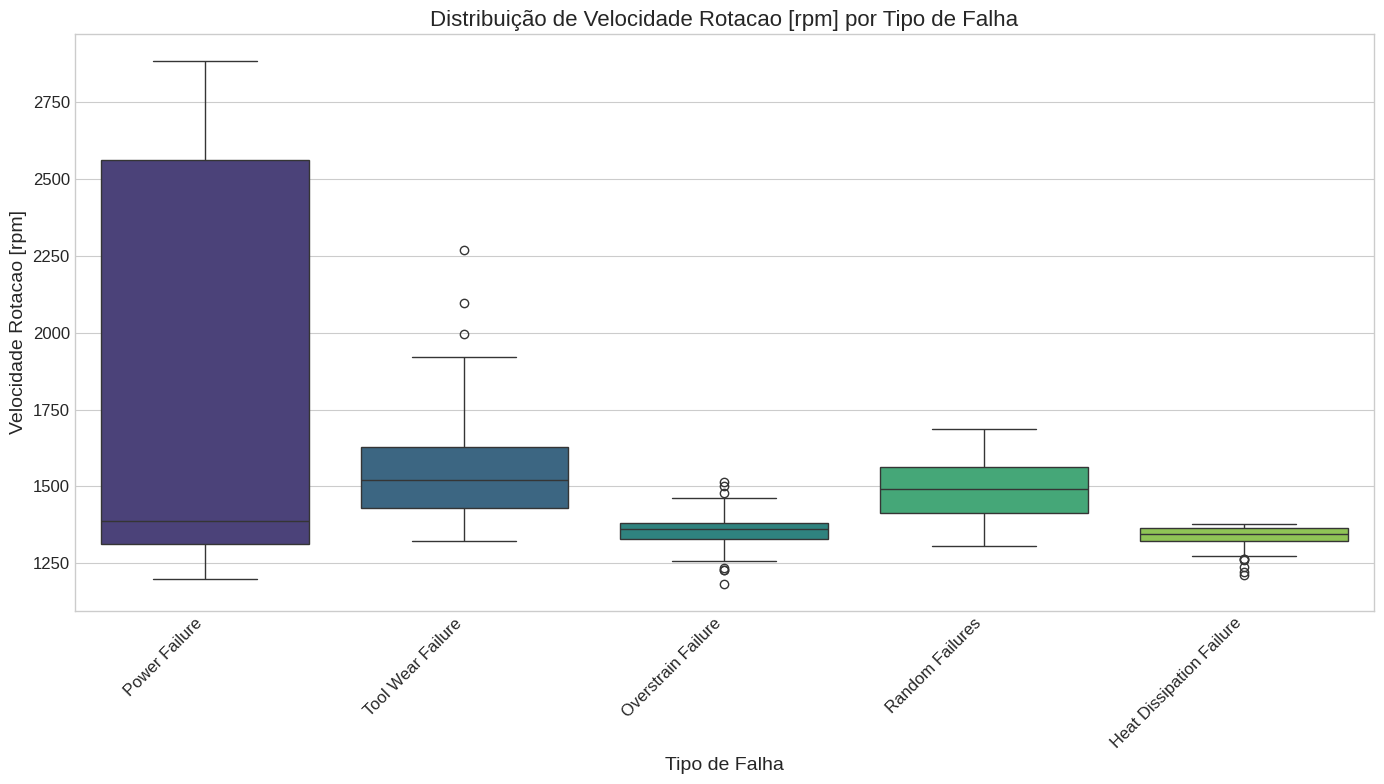

<ipython-input-7-d61a0fade2e7>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Tipo da Falha', y=var, data=df_falhas, palette='viridis')


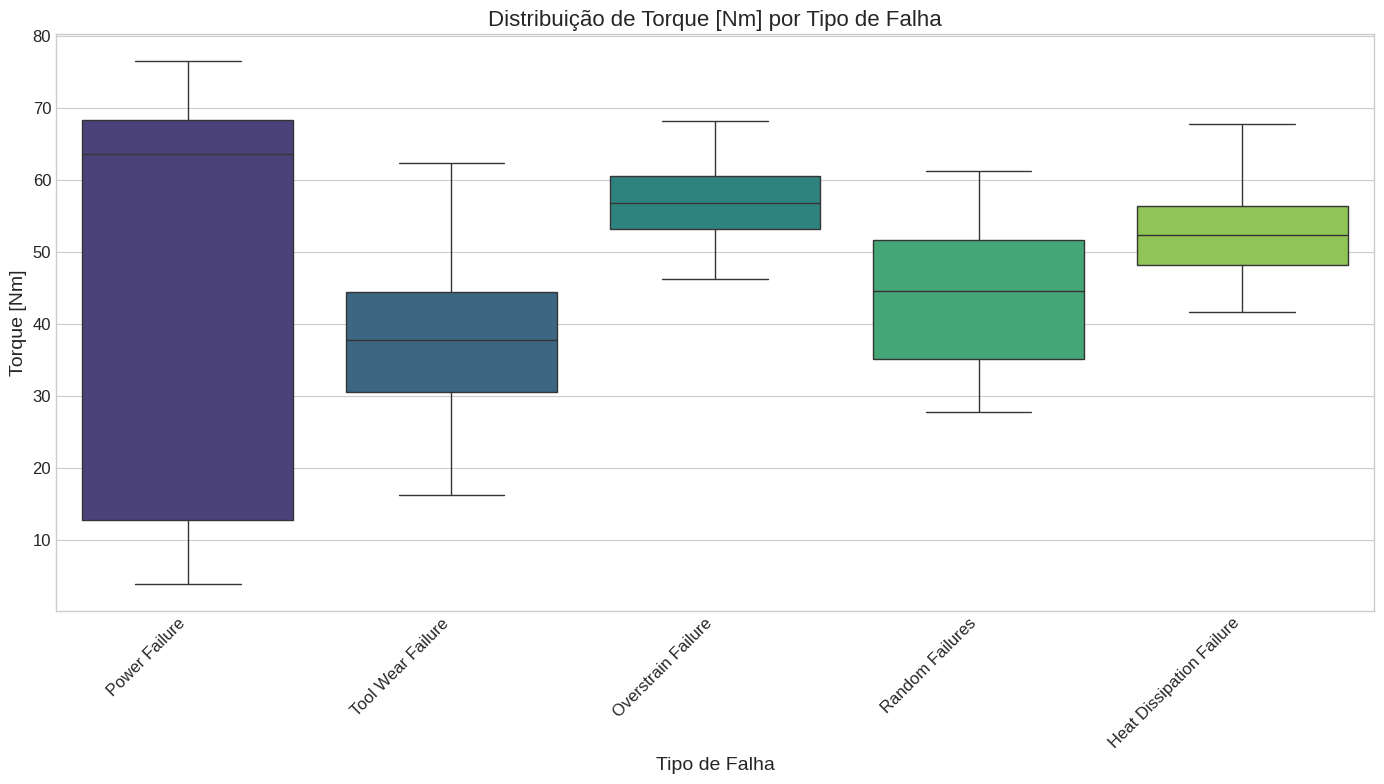

<ipython-input-7-d61a0fade2e7>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Tipo da Falha', y=var, data=df_falhas, palette='viridis')


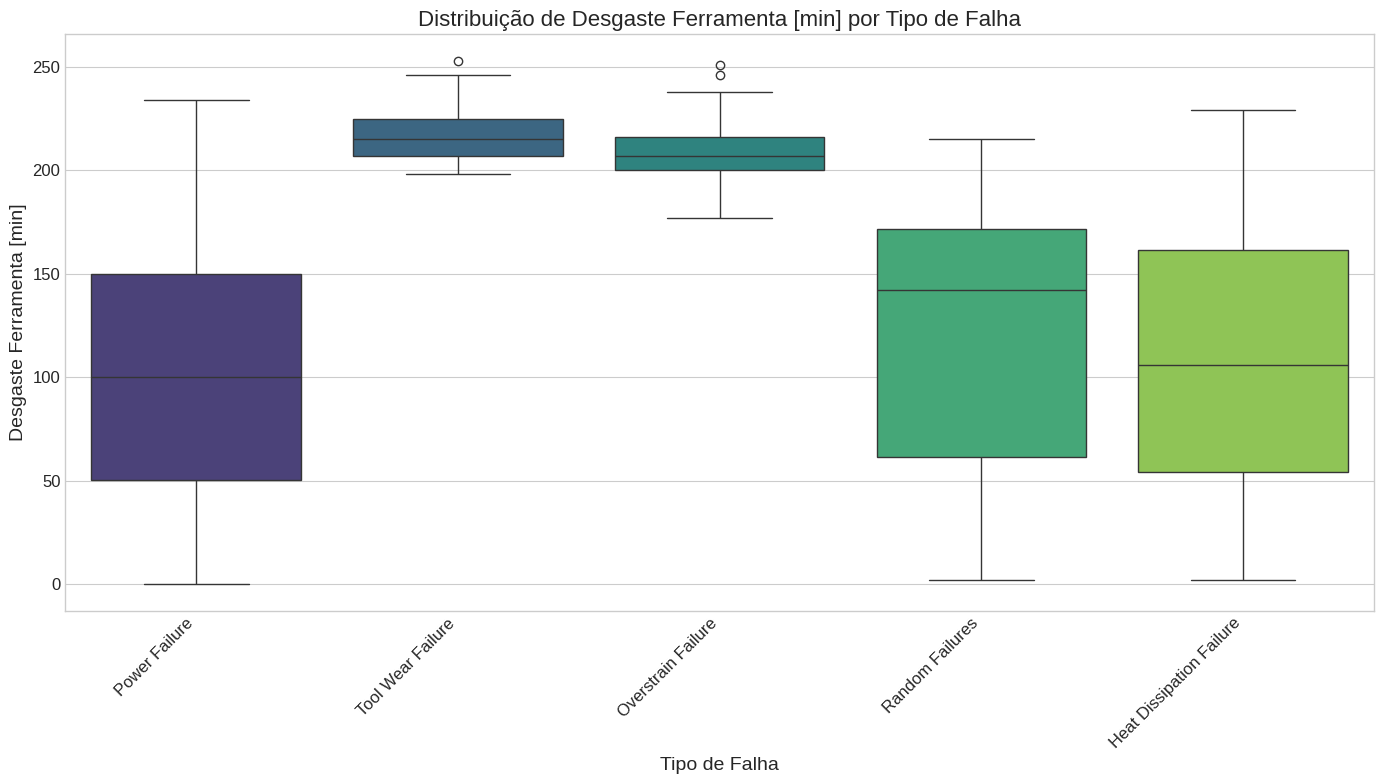

In [ ]:
# variáveis numéricas para análise
numeric_vars = ['Temperatura Ar [K]', 'Temperatura Processo [K]',
                'Velocidade Rotacao [rpm]', 'Torque [Nm]', 'Desgaste Ferramenta [min]']


# Estatísticas descritivas por tipo de falha
print("\n=== Estatísticas Descritivas por Tipo de Falha ===")
for tipo in tipos_falha:
    print(f"\nEstatísticas para {tipo}:")
    subset = df_falhas[df_falhas['Tipo da Falha'] == tipo]
    print(subset[numeric_vars].describe())


    # Boxplots para cada variável numérica por tipo de falha
for var in numeric_vars:
    plt.figure(figsize=(14, 8))
    ax = sns.boxplot(x='Tipo da Falha', y=var, data=df_falhas, palette='viridis')
    plt.title(f'Distribuição de {var} por Tipo de Falha', fontsize=16)
    plt.xlabel('Tipo de Falha', fontsize=14)
    plt.ylabel(var, fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



=== Matrizes de Correlação por Tipo de Falha ===

Matriz de correlação para Power Failure:
                           Temperatura Ar [K]  Temperatura Processo [K]  \
Temperatura Ar [K]                       1.00                      0.90   
Temperatura Processo [K]                 0.90                      1.00   
Velocidade Rotacao [rpm]                 0.04                      0.03   
Torque [Nm]                             -0.04                     -0.02   
Desgaste Ferramenta [min]               -0.04                     -0.08   

                           Velocidade Rotacao [rpm]  Torque [Nm]  \
Temperatura Ar [K]                             0.04        -0.04   
Temperatura Processo [K]                       0.03        -0.02   
Velocidade Rotacao [rpm]                       1.00        -0.99   
Torque [Nm]                                   -0.99         1.00   
Desgaste Ferramenta [min]                     -0.05         0.04   

                           Desgaste Ferramenta [

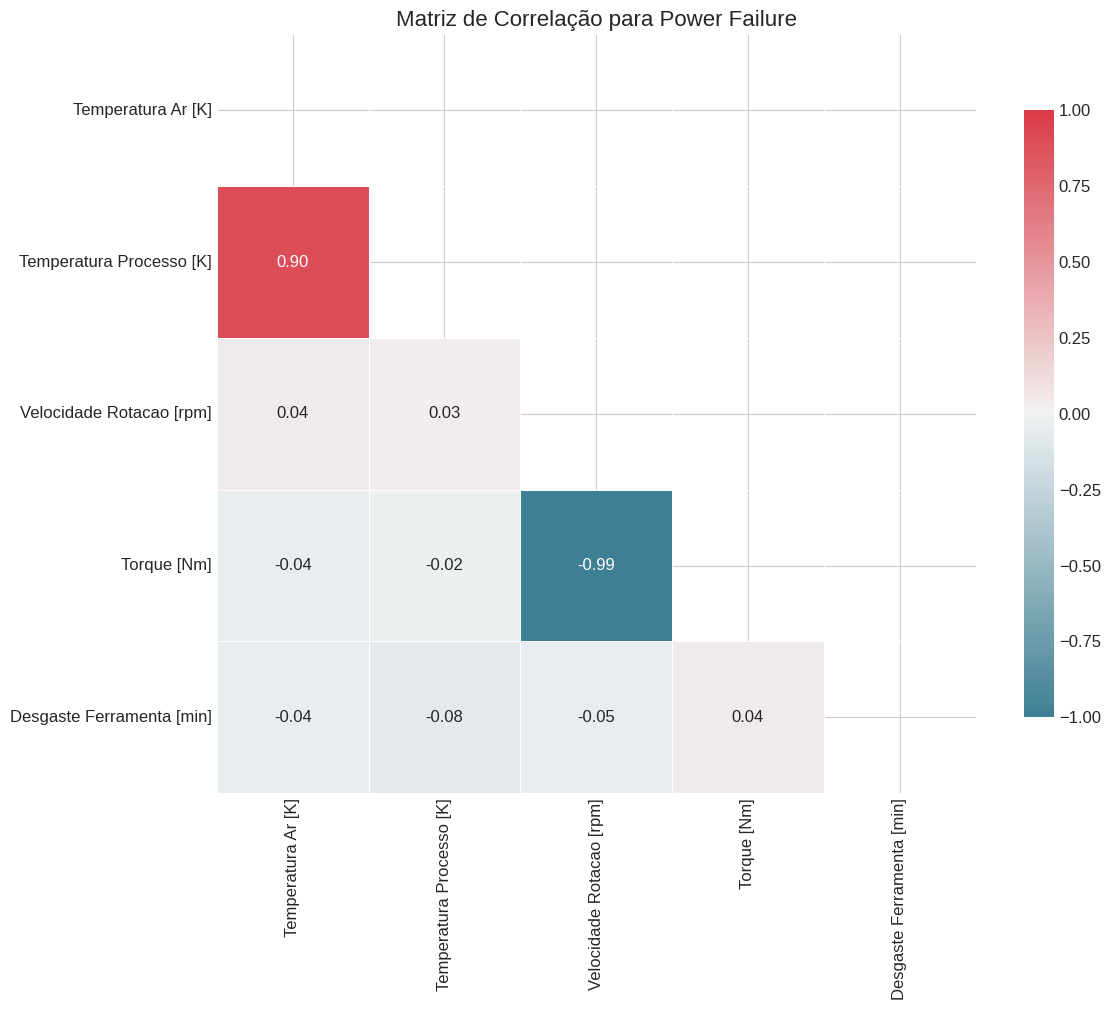


Matriz de correlação para Tool Wear Failure:
                           Temperatura Ar [K]  Temperatura Processo [K]  \
Temperatura Ar [K]                       1.00                      0.84   
Temperatura Processo [K]                 0.84                      1.00   
Velocidade Rotacao [rpm]                -0.07                      0.05   
Torque [Nm]                              0.10                      0.03   
Desgaste Ferramenta [min]                0.28                      0.21   

                           Velocidade Rotacao [rpm]  Torque [Nm]  \
Temperatura Ar [K]                            -0.07         0.10   
Temperatura Processo [K]                       0.05         0.03   
Velocidade Rotacao [rpm]                       1.00        -0.88   
Torque [Nm]                                   -0.88         1.00   
Desgaste Ferramenta [min]                      0.06         0.06   

                           Desgaste Ferramenta [min]  
Temperatura Ar [K]                     

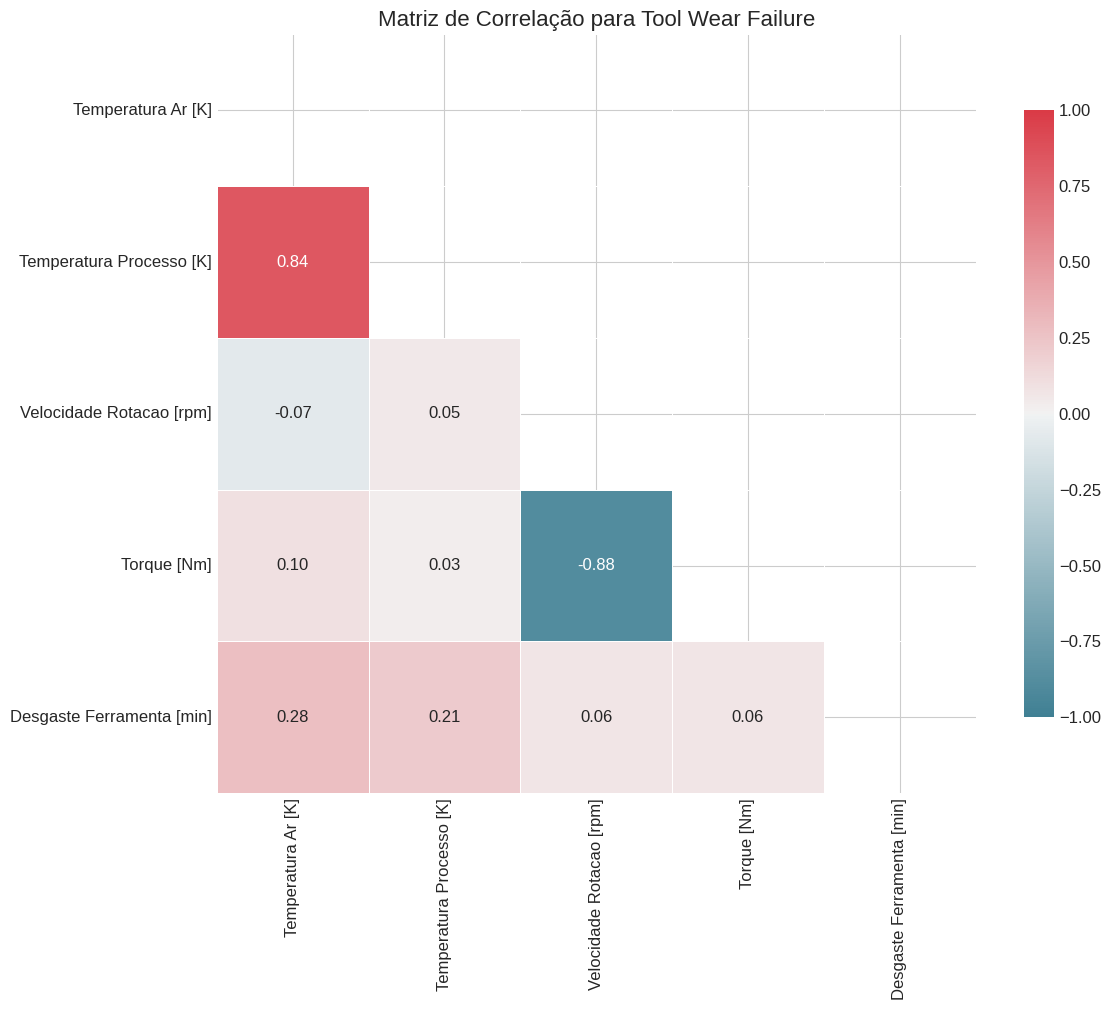


Matriz de correlação para Overstrain Failure:
                           Temperatura Ar [K]  Temperatura Processo [K]  \
Temperatura Ar [K]                       1.00                      0.90   
Temperatura Processo [K]                 0.90                      1.00   
Velocidade Rotacao [rpm]                -0.04                     -0.05   
Torque [Nm]                              0.09                      0.07   
Desgaste Ferramenta [min]               -0.06                     -0.02   

                           Velocidade Rotacao [rpm]  Torque [Nm]  \
Temperatura Ar [K]                            -0.04         0.09   
Temperatura Processo [K]                      -0.05         0.07   
Velocidade Rotacao [rpm]                       1.00        -0.77   
Torque [Nm]                                   -0.77         1.00   
Desgaste Ferramenta [min]                      0.50        -0.70   

                           Desgaste Ferramenta [min]  
Temperatura Ar [K]                    

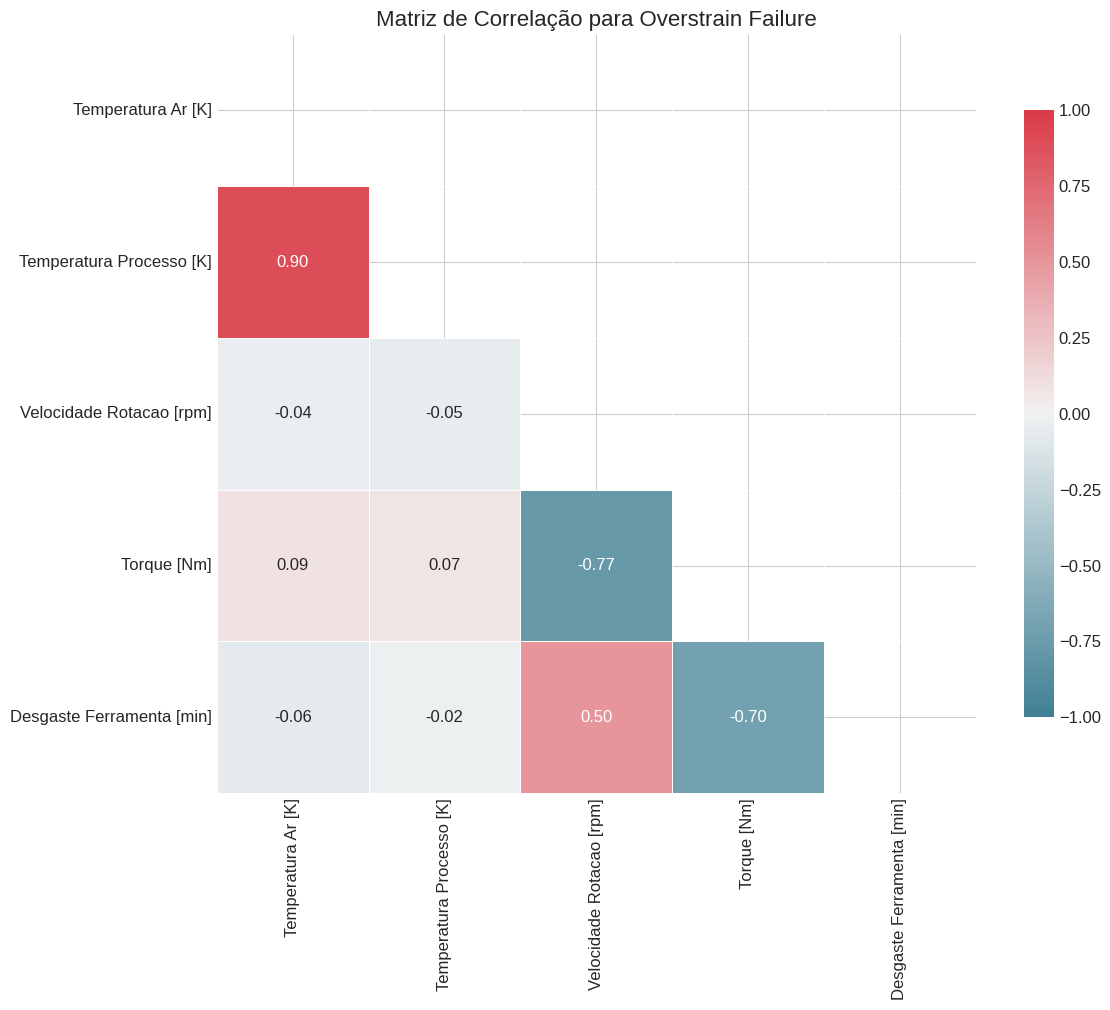


Matriz de correlação para Random Failures:
                           Temperatura Ar [K]  Temperatura Processo [K]  \
Temperatura Ar [K]                       1.00                      0.88   
Temperatura Processo [K]                 0.88                      1.00   
Velocidade Rotacao [rpm]                -0.18                     -0.35   
Torque [Nm]                              0.14                      0.29   
Desgaste Ferramenta [min]               -0.15                     -0.12   

                           Velocidade Rotacao [rpm]  Torque [Nm]  \
Temperatura Ar [K]                            -0.18         0.14   
Temperatura Processo [K]                      -0.35         0.29   
Velocidade Rotacao [rpm]                       1.00        -0.93   
Torque [Nm]                                   -0.93         1.00   
Desgaste Ferramenta [min]                      0.12        -0.17   

                           Desgaste Ferramenta [min]  
Temperatura Ar [K]                       

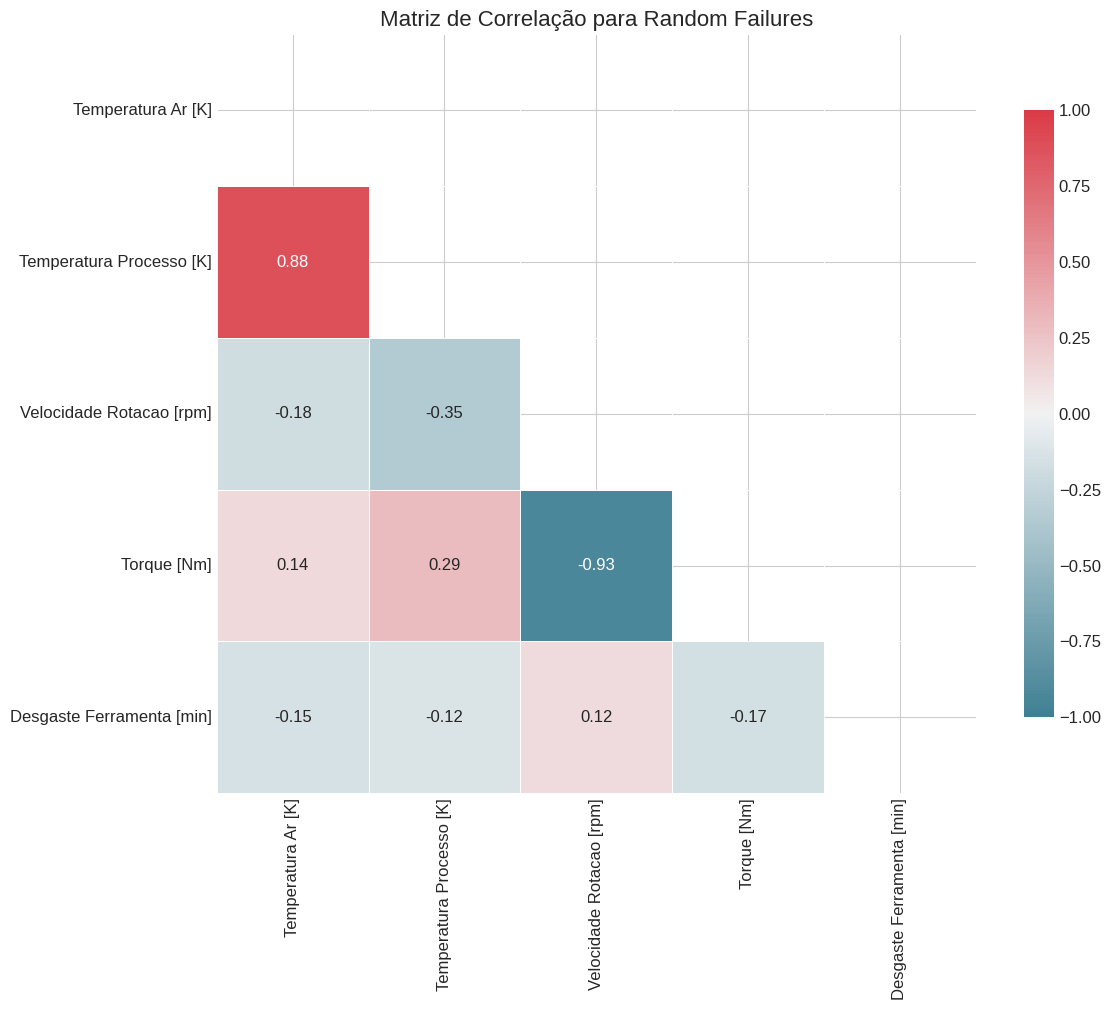


Matriz de correlação para Heat Dissipation Failure:
                           Temperatura Ar [K]  Temperatura Processo [K]  \
Temperatura Ar [K]                       1.00                      0.90   
Temperatura Processo [K]                 0.90                      1.00   
Velocidade Rotacao [rpm]                -0.02                     -0.01   
Torque [Nm]                             -0.11                     -0.12   
Desgaste Ferramenta [min]               -0.04                     -0.04   

                           Velocidade Rotacao [rpm]  Torque [Nm]  \
Temperatura Ar [K]                            -0.02        -0.11   
Temperatura Processo [K]                      -0.01        -0.12   
Velocidade Rotacao [rpm]                       1.00        -0.55   
Torque [Nm]                                   -0.55         1.00   
Desgaste Ferramenta [min]                     -0.04         0.01   

                           Desgaste Ferramenta [min]  
Temperatura Ar [K]              

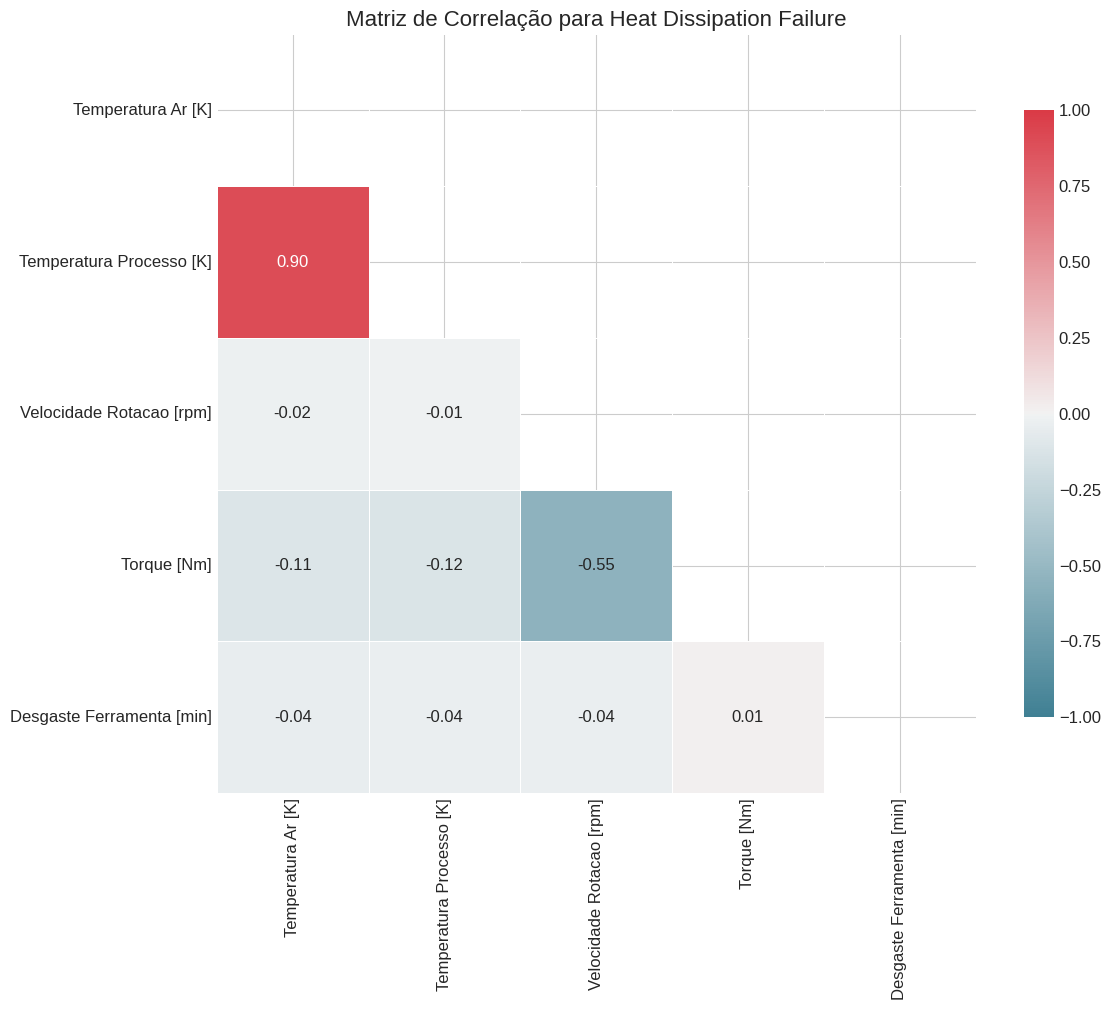

In [ ]:
# Análise de correlação entre variáveis para cada tipo de falha


# matrizes de correlação para cada tipo de falha
print("\n=== Matrizes de Correlação por Tipo de Falha ===")


# paleta de cores para heatmaps
cmap = sns.diverging_palette(220, 10, as_cmap=True)


for tipo in tipos_falha:
    subset = df_falhas[df_falhas['Tipo da Falha'] == tipo]

    # Calcular a matriz de correlação
    corr_matrix = subset[numeric_vars].corr()

    print(f"\nMatriz de correlação para {tipo}:")
    print(corr_matrix.round(2))

    # Visualizar a matriz de correlação como um heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
                annot=True, fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .8})
    plt.title(f'Matriz de Correlação para {tipo}', fontsize=16)
    plt.tight_layout()
    plt.show()
